# 09 — Rolling market-regime evaluation
Evaluate the fixed RNN and CA-RNN specifications, together with the temporal-penalty-removal ablation, on four non-overlapping chronological test regimes. Training expands through time; every validation and test period is strictly later than its training period. Five matched optimization seeds are used per regime.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import CARNNConfig, TrainingConfig
from innovcal.evaluation import paired_seed_block_bootstrap
from innovcal.experiments import RegimeDefinition, run_regime_seed_comparison
OUT = ROOT / 'results' / 'market_regimes'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
returns = pd.read_csv(ROOT / 'data' / 'processed' / 'financial_returns.csv', index_col=0, parse_dates=True)
returns = returns[['AAPL', 'JPM', 'XOM', 'WMT']].dropna().sort_index()
REGIMES = [
    RegimeDefinition('pre_pandemic', '2007-01-01', '2014-12-31', '2015-01-01', '2016-12-31', '2017-01-01', '2019-12-31'),
    RegimeDefinition('pandemic', '2007-01-01', '2016-12-31', '2017-01-01', '2019-12-31', '2020-01-01', '2021-12-31'),
    RegimeDefinition('inflation_tightening', '2007-01-01', '2019-12-31', '2020-01-01', '2021-12-31', '2022-01-01', '2023-12-31'),
    RegimeDefinition('recent', '2007-01-01', '2021-12-31', '2022-01-01', '2023-12-31', '2024-01-01', '2025-12-31'),
]
SEEDS = [701, 709, 719, 727, 733]
pd.DataFrame([vars(regime) for regime in REGIMES])

,name,train_start,train_end,validation_start,validation_end,test_start,test_end
0,pre_pandemic,2007-01-01,2014-12-31,2015-01-01,2016-12-31,2017-01-01,2019-12-31
1,pandemic,2007-01-01,2016-12-31,2017-01-01,2019-12-31,2020-01-01,2021-12-31
2,inflation_tightening,2007-01-01,2019-12-31,2020-01-01,2021-12-31,2022-01-01,2023-12-31
3,recent,2007-01-01,2021-12-31,2022-01-01,2023-12-31,2024-01-01,2025-12-31


## Fit or load each regime
This cell performs up to 60 fits (four regimes × five seeds × three models). Each completed regime is saved immediately. If execution is interrupted, rerunning skips completed regimes. Delete an individual regime's `.npz` and `.csv` files only if that regime must be refitted.

In [3]:
training = TrainingConfig(epochs=200, batch_size=64, patience=25, selection_metric='nll')
regime_results = {}
metric_frames = []
for regime in REGIMES:
    archive_path = OUT / f'{regime.name}_forecasts.npz'
    metrics_path = OUT / f'{regime.name}_metrics.csv'
    if archive_path.exists() and metrics_path.exists():
        archive = np.load(archive_path)
        names = [str(value) for value in archive['model_names']]
        stored_names = names.copy()
        if len(names) == 3 and 'CA-RNN (temporal penalty removed)' not in names:
            names = ['RNN', 'CA-RNN (temporal penalty removed)', 'CA-RNN']
        forecasts = {name: archive[f'samples_{index}'] for index, name in enumerate(names)}
        regime_results[regime.name] = {'target': archive['target'], 'projections': archive['projections'], 'forecasts': forecasts}
        frame = pd.read_csv(metrics_path)
        frame['model'] = frame['model'].replace(dict(zip(stored_names, names)))
        print(f'Loaded {regime.name}')
    else:
        fitted = run_regime_seed_comparison(
            returns.to_numpy(), returns.index.to_numpy(), regime, SEEDS,
            model_config=CARNNConfig(input_dim=4, hidden_dim=32),
            training_config=training, lambda_cal=100.0, lambda_seq=2000.0,
            projection_seed=606, forecast_seed=20_606, n_forecast_samples=500,
        )
        names = list(fitted.forecast_samples)
        payload = {'target': fitted.target, 'projections': fitted.projections, 'model_names': np.asarray(names)}
        payload.update({f'samples_{index}': fitted.forecast_samples[name] for index, name in enumerate(names)})
        np.savez_compressed(archive_path, **payload)
        fitted.metrics.to_csv(metrics_path, index=False)
        regime_results[regime.name] = {'target': fitted.target, 'projections': fitted.projections, 'forecasts': fitted.forecast_samples}
        frame = fitted.metrics
        print(f'Fitted and saved {regime.name}')
    metric_frames.append(frame)
all_metrics = pd.concat(metric_frames, ignore_index=True)
display(all_metrics.groupby(['regime', 'model'])[['rmse', 'energy_score', 'interval_score', 'coverage', 'pit_calibration_error']].mean())

Loaded pre_pandemic
Loaded pandemic
Loaded inflation_tightening
Loaded recent


rmse  \
regime               model                                         
inflation_tightening CA-RNN                             1.039760   
                     CA-RNN (temporal penalty removed)  1.041331   
                     RNN                                1.031163   
pandemic             CA-RNN                             1.295048   
                     CA-RNN (temporal penalty removed)  1.299335   
                     RNN                                1.293362   
pre_pandemic         CA-RNN                             0.725115   
                     CA-RNN (temporal penalty removed)  0.725994   
                     RNN                                0.724820   
recent               CA-RNN                             0.852731   
                     CA-RNN (temporal penalty removed)  0.855046   
                     RNN                                0.846811   

                                                        energy_score  \
regime               model                                             
inflation_tightening CA-RNN                                 1.288410   
                     CA-RNN (temporal penalty removed)      1.292710   
                     RNN                                    1.280927   
pandemic             CA-RNN                                 1.502884   
                     CA-RNN (temporal penalty removed)      1.515014   
                     RNN                                    1.501580   
pre_pandemic         CA-RNN                                 0.862631   
                     CA-RNN (temporal penalty removed)      0.863544   
                     RNN                                    0.862865   
recent               CA-RNN                                 1.028901   
                     CA-RNN (temporal penalty removed)      1.031020   
                     RNN                                    1.023692   

                                                        interval_score  \
regime               model                                               
inflation_tightening CA-RNN                                   4.539620   
                     CA-RNN (temporal penalty removed)        4.588601   
                     RNN                                      4.586208   
pandemic             CA-RNN                                   5.662879   
                     CA-RNN (temporal penalty removed)        5.811076   
                     RNN                                      5.737105   
pre_pandemic         CA-RNN                                   3.102716   
                     CA-RNN (temporal penalty removed)        3.108802   
                     RNN                                      3.112342   
recent               CA-RNN                                   3.693527   
                     CA-RNN (temporal penalty removed)        3.720035   
                     RNN                                      3.664792   

                                                        coverage  \
regime               model                                         
inflation_tightening CA-RNN                             0.876148   
                     CA-RNN (temporal penalty removed)  0.858383   
                     RNN                                0.852295   
pandemic             CA-RNN                             0.817723   
                     CA-RNN (temporal penalty removed)  0.801881   
                     RNN                                0.814554   
pre_pandemic         CA-RNN                             0.912401   
                     CA-RNN (temporal penalty removed)  0.911074   
                     RNN                                0.917374   
recent               CA-RNN                             0.884661   
                     CA-RNN (temporal penalty removed)  0.879980   
                     RNN                                0.890837   

                                                        pit_calibration_error  
regime               model  

In [4]:
COMPARISONS = [('CA-RNN (temporal penalty removed)', 'RNN'), ('CA-RNN', 'CA-RNN (temporal penalty removed)'), ('CA-RNN', 'RNN')]
inference_frames = []
for number, regime in enumerate(REGIMES):
    stored = regime_results[regime.name]
    frame = paired_seed_block_bootstrap(
        stored['target'], stored['forecasts'], COMPARISONS, stored['projections'],
        block_length=20, n_bootstrap=1000, confidence=0.95, seed=900 + number,
    )
    frame.insert(0, 'regime', regime.name)
    inference_frames.append(frame)
regime_inference = pd.concat(inference_frames, ignore_index=True)
regime_inference.to_csv(OUT / 'regime_hierarchical_inference.csv', index=False)
display(regime_inference[regime_inference.metric.isin(['energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error'])])

,regime,n_seeds,n_origins,block_length,n_bootstrap,candidate,comparator,metric,difference,bootstrap_se,ci_lower,ci_upper,probability_difference_below_zero
1,pre_pandemic,5,754,20,1000,CA-RNN (temporal penalty removed),RNN,energy_score,0.000679,0.001125,-0.001554,0.002850,0.337
2,pre_pandemic,5,754,20,1000,CA-RNN (temporal penalty removed),RNN,interval_score,-0.003540,0.010740,-0.021827,0.019692,0.666
5,pre_pandemic,5,754,20,1000,CA-RNN (temporal penalty removed),RNN,coverage_error,-0.006300,0.002704,-0.010041,0.000186,0.971
6,pre_pandemic,5,754,20,1000,CA-RNN (temporal penalty removed),RNN,pit_calibration_error,-0.000287,0.000195,-0.000669,0.000091,0.935
9,pre_pandemic,5,754,20,1000,CA-RNN,CA-RNN (temporal penalty removed),energy_score,-0.000913,0.001008,-0.002891,0.001077,0.771
10,pre_pandemic,5,754,20,1000,CA-RNN,CA-RNN (temporal penalty removed),interval_score,-0.006086,0.009175,-0.025809,0.009419,0.683
13,pre_pandemic,5,754,20,1000,CA-RNN,CA-RNN (temporal penalty removed),coverage_error,0.001326,0.002865,-0.005651,0.005439,0.409
14,pre_pandemic,5,754,20,1000,CA-RNN,CA-RNN (temporal penalty removed),pit_calibration_error,-0.000124,0.000187,-0.000508,0.000218,0.728
17,pre_pandemic,5,754,20,1000,CA-RNN,RNN,energy_score,-0.000234,0.000773,-0.001678,0.001280,0.628
18,pre_pandemic,5,754,20,1000,CA-RNN,RNN,interval_score,-0.009626,0.005637,-0.019631,0.002951,0.944


In [5]:
loss_metrics = {'mean_squared_error', 'energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error', 'pit_mean_absolute_autocorrelation'}
decisions = regime_inference.assign(interval_excludes_zero=(regime_inference.ci_lower > 0) | (regime_inference.ci_upper < 0))
decisions['direction'] = 'descriptive'
is_loss = decisions.metric.isin(loss_metrics)
decisions.loc[is_loss & (decisions.ci_upper < 0), 'direction'] = 'candidate favored'
decisions.loc[is_loss & (decisions.ci_lower > 0), 'direction'] = 'comparator favored'
decisions.loc[is_loss & ~decisions.interval_excludes_zero, 'direction'] = 'unresolved'
decisions.to_csv(OUT / 'regime_decisions.csv', index=False)
display(pd.crosstab([decisions.candidate, decisions.comparator, decisions.metric], decisions.direction))

direction                                                                                              candidate favored  \
candidate                         comparator                        metric                                                 
CA-RNN                            CA-RNN (temporal penalty removed) coverage                                           0   
                                                                    coverage_error                                     3   
                                                                    energy_score                                       3   
                                                                    interval_score                                     3   
                                                                    interval_width                                     0   
                                                                    mean_squared_error                                 2   
                                                                    pit_calibration_error                              2   
                                                                    pit_mean_absolute_autocorrelation                  1   
                                  RNN                               coverage                                           0   
                                                                    coverage_error                                     2   
                                                                    energy_score                                       0   
                                                                    interval_score                                     2   
                                                                    interval_width                                     0   
                                                                    mean_squared_error                                 0   
                                                                    pit_calibration_error                              3   
                                                                    pit_mean_absolute_autocorrelation                  0   
CA-RNN (temporal penalty removed) RNN                               coverage                                           0   
                                                                    coverage_error                                     0   
                                                                    energy_score                                       0   
                                                                    interval_score                                     0   
                                                                    interval_width                                     0   
                                                                    mean_squared_error                                 0   
                                                                    pit_calibration_error                              1   
                                                                    pit_mean_absolute_autocorrelation                  0   

direction                                                                                              comparator favored  \
candidate                         comparator                        metric                                                  
CA-RNN                            CA-RNN (temporal penalty removed) coverage                                            0   
                                                                    coverage_error                                      0   
                                                                    energy_score                                        0   
                                                                    interval_score                                      0   
                         

In [6]:
metrics = ['energy_score', 'interval_score', 'pit_calibration_error']
means = all_metrics.groupby(['regime', 'model'])[metrics].mean().unstack('model')
rows = []
for candidate, comparator in COMPARISONS:
    for metric in metrics:
        differences = means[metric][candidate] - means[metric][comparator]
        rows.append({'candidate': candidate, 'comparator': comparator, 'metric': metric, 'mean_across_regimes': differences.mean(), 'median_across_regimes': differences.median(), 'regimes_candidate_lower': int((differences < 0).sum()), 'n_regimes': len(differences)})
cross_regime = pd.DataFrame(rows)
cross_regime.to_csv(OUT / 'cross_regime_summary.csv', index=False)
display(cross_regime)

,candidate,comparator,metric,mean_across_regimes,median_across_regimes,regimes_candidate_lower,n_regimes
0,CA-RNN (temporal penalty removed),RNN,energy_score,0.008306,0.009556,0,4
1,CA-RNN (temporal penalty removed),RNN,interval_score,0.032017,0.028818,1,4
2,CA-RNN (temporal penalty removed),RNN,pit_calibration_error,-0.000048,-0.000209,3,4
3,CA-RNN,CA-RNN (temporal penalty removed),energy_score,-0.004866,-0.003210,4,4
4,CA-RNN,CA-RNN (temporal penalty removed),interval_score,-0.057443,-0.037745,4,4
5,CA-RNN,CA-RNN (temporal penalty removed),pit_calibration_error,-0.000256,-0.000185,3,4
6,CA-RNN,RNN,energy_score,0.003440,0.003256,1,4
7,CA-RNN,RNN,interval_score,-0.025426,-0.028107,3,4
8,CA-RNN,RNN,pit_calibration_error,-0.000305,-0.000348,4,4


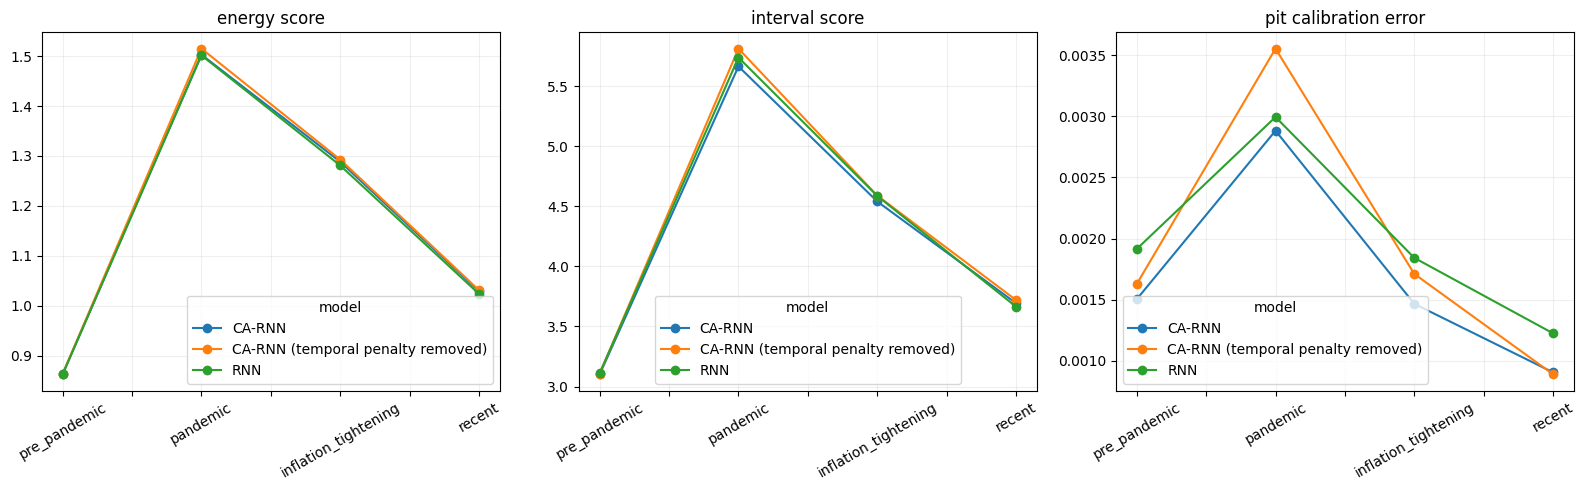

In [7]:
plot_data = all_metrics.groupby(['regime', 'model'])[['energy_score', 'interval_score', 'pit_calibration_error']].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for axis, metric in zip(axes, ['energy_score', 'interval_score', 'pit_calibration_error']):
    pivot = plot_data.pivot(index='regime', columns='model', values=metric).reindex([r.name for r in REGIMES])
    pivot.plot(ax=axis, marker='o'); axis.set_title(metric.replace('_', ' ')); axis.set_xlabel(''); axis.tick_params(axis='x', rotation=30); axis.grid(alpha=.2)
plt.tight_layout()
fig.savefig(OUT / 'regime_metric_profiles.png', dpi=180, bbox_inches='tight')

## Interpretation rules
Treat each regime as a distinct external-validity check, not as an iid replication. The within-regime hierarchical intervals include optimization-seed and serial test-origin variability. Cross-regime means and sign counts are descriptive because four regimes are too few for reliable asymptotic inference. Hyperparameters remain fixed at the values selected before these regime tests. Results should be judged by consistency of the calibration–proper-score tradeoff, not by whether one model wins every metric in every period.